# Reproduce the insider-trading pipeline using `polycluster`

This notebook fetches markets, computes per-(wallet, market) behavioral features, and trains a logistic-regression classifier to flag insider trading — using only the public API of the `polycluster` package.

* 8 insider entries across 7 main markets (one market is reused with a second insider)
* 5 insider entries on the `us-strikes-iran` market
* 8 random non-insider wallets sampled per main market (excluding the warpowers market)
* Same `random.seed(42)`, same `>50 trades` filter, same `major_move_kwargs`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random

import numpy as np
import pandas as pd

import polycluster as pc
from polycluster import (
    DEFAULT_BEHAVIORAL_FEATURES,
    build_history_df_from_orderfilled,
    compute_market_user_features,
    fit_final_logistic,
    get_market_by_slug,
    get_market_orderfilled_events,
    get_misclassified_rows,
    impute_feature_only_df,
    nested_kfold_loocv_logistic,
    parse_orderfilled_events,
    score_new_rows,
    tune_C_loocv_logistic,
)

## Constants — the same wallets / slugs as the original notebook

In [ ]:
# (insider_wallet, market_slug) pairs for the 8 insider entries from
# the main markets. Note that the maduro market appears twice with
# two different insider wallets.
INSIDER_PAIRS = [
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-d4vd-be-the-1-searched-person-on-google-this-year'),
    ('0x31a56e9e690c621ed21de08cb559e9524cdb8ed9', 'us-forces-in-venezuela-by-january-31-2026'),
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-gemini-3pt0-be-released-on-november-18-2025'),
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-gemini-3pt0-be-released-by-october-31-881-568-524'),
    ('0x31a56e9e690c621ed21de08cb559e9524cdb8ed9', 'maduro-out-by-january-31-2026-318'),
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year'),
    ('0x31a56e9e690c621ed21de08cb559e9524cdb8ed9', 'trump-invokes-war-powers-against-venezuela-by-january-31-134-583'),
    ('0xa72db1749e9ac2379d49a3c12708325ed17febd4', 'maduro-out-by-january-31-2026-318'),
]

# Markets to use as the pool for sampling non-insider ("normal") wallets.
# and skips the duplicated maduro entry.
NORMAL_SAMPLE_SLUGS = [
    'will-d4vd-be-the-1-searched-person-on-google-this-year',
    'us-forces-in-venezuela-by-january-31-2026',
    'will-gemini-3pt0-be-released-on-november-18-2025',
    'will-gemini-3pt0-be-released-by-october-31-881-568-524',
    'maduro-out-by-january-31-2026-318',
    'will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year',
]

# Insider wallet to exclude from sampling for each normal-sample slug
# excluded, even where two insiders exist for one market).
INSIDER_BY_NORMAL_SLUG = {
    'will-d4vd-be-the-1-searched-person-on-google-this-year': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
    'us-forces-in-venezuela-by-january-31-2026': '0x31a56e9e690c621ed21de08cb559e9524cdb8ed9',
    'will-gemini-3pt0-be-released-on-november-18-2025': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
    'will-gemini-3pt0-be-released-by-october-31-881-568-524': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
    'maduro-out-by-january-31-2026-318': '0x31a56e9e690c621ed21de08cb559e9524cdb8ed9',
    'will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
}

# 228 event (us-strikes-iran) and its 5 insider wallets.
IRAN_SLUG = 'us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761'
IRAN_INSIDERS = [
    '0xdde15ebd95330ce69136dc0ccd810d22382e02c5',
    '0x56efadc9defe5b7a21af751e0d026f2cf54136db',
    '0x38745db27f7360a287f6ca3c9b6a6a9c76149801',
    '0x1caa6a7ad0c6916aef7b67946de2e57ad24846a0',
    '0xa4eb52229991c074bc560f825bf2776d77acd010',
]

# Same major-move detection settings as the original notebook.
MAJOR_MOVE_KWARGS = {
    'lookahead_sec': 3600,
    'abs_move_threshold': 0.15,
    'upward_only': False,
}

# Filter applied when sampling normals — only consider wallets with
# a meaningful number of trades on the market.
MIN_TRADES_FOR_NORMAL = 50
NORMALS_PER_MARKET = 8
RANDOM_SEED = 42

## Fetch + parse each market exactly once

Pulling OrderFilled events from the subgraph.


In [4]:
ALL_SLUGS = sorted({slug for _, slug in INSIDER_PAIRS} | set(NORMAL_SAMPLE_SLUGS) | {IRAN_SLUG})
print(f'Will fetch {len(ALL_SLUGS)} unique markets')

# market_cache[slug] = {
#   'market': Market,
#   'events': list[dict],   # raw OrderFilled events
#   'history': pd.DataFrame, # YES-price history
#   'parsed':  dict,         # output of parse_orderfilled_events
# }
market_cache: dict[str, dict] = {}

for slug in ALL_SLUGS:
    print(f'\n--- {slug} ---')
    market = get_market_by_slug(slug)
    events = get_market_orderfilled_events(market, verbose=True)
    history = build_history_df_from_orderfilled(
        events, market.yes_token_id, market.no_token_id,
    )
    parsed = parse_orderfilled_events(events, market.token_ids, market.outcomes)
    market_cache[slug] = {
        'market': market,
        'events': events,
        'history': history,
        'parsed': parsed,
    }
    print(f'  events={len(events)}, wallets={len(parsed["wallet_trades"])}')

Will fetch 8 unique markets

--- maduro-out-by-january-31-2026-318 ---
[polycluster] get_orderfilled_events: 2 token(s), window=[1765499254, 1767442447] (1943193s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 4174 rows in 28.0s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 8658 rows in 57.5s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 4198 rows in 26.5s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 9337 rows in 74.1s
[polycluster] get_orderfilled_events: done, 26367 unique rows in 186.2s
  events=26367, wallets=3947

--- trump-invokes-war-powers-against-venezuela-by-january-31-134-583 ---
[polycluster] get_orderfilled_events: 2 token(s), window=[1766090403, 1767723057] (1632654s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side

## Build one (wallet, market) feature row

In [5]:
def build_feature_row(wallet: str, slug: str) -> dict:
    """Compute the full feature dict for a single (wallet, market) pair."""
    cache = market_cache[slug]
    market = cache['market']
    parsed_trades = cache['parsed']['wallet_trades'].get(wallet.lower(), [])

    final_outcome_yes = (
        1 if (market.closed and market.outcome_prices and float(market.outcome_prices[0]) >= 0.5)
        else 0 if (market.closed and market.outcome_prices)
        else None
    )

    feats = compute_market_user_features(
        parsed_trades=parsed_trades,
        history_df=cache['history'],
        market_start_time=market.start_ts,
        market_end_time=market.end_ts,
        final_outcome_yes=final_outcome_yes,
        major_move_kwargs=MAJOR_MOVE_KWARGS,
    )
    feats['wallet'] = wallet
    feats['market_slug'] = slug
    return feats

## Insider rows — 8 from main markets + 5 from the 228 event

In [6]:
insider_rows: list[dict] = []

for wallet, slug in INSIDER_PAIRS:
    insider_rows.append(build_feature_row(wallet, slug))

for wallet in IRAN_INSIDERS:
    insider_rows.append(build_feature_row(wallet, IRAN_SLUG))

insider_raw_df = pd.DataFrame(insider_rows)
print(f'insider_raw_df: {insider_raw_df.shape}')
insider_raw_df[['wallet', 'market_slug']]

insider_raw_df: (13, 321)


,wallet,market_slug
0,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-d4vd-be-the-1-searched-person-on-google-t...
1,0x31a56e9e690c621ed21de08cb559e9524cdb8ed9,us-forces-in-venezuela-by-january-31-2026
2,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-gemini-3pt0-be-released-on-november-18-2025
3,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-gemini-3pt0-be-released-by-october-31-881...
4,0x31a56e9e690c621ed21de08cb559e9524cdb8ed9,maduro-out-by-january-31-2026-318
5,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-pope-leo-xiv-be-the-1-searched-person-on-...
6,0x31a56e9e690c621ed21de08cb559e9524cdb8ed9,trump-invokes-war-powers-against-venezuela-by-...
7,0xa72db1749e9ac2379d49a3c12708325ed17febd4,maduro-out-by-january-31-2026-318
8,0xdde15ebd95330ce69136dc0ccd810d22382e02c5,us-strikes-iran-by-february-28-2026-227-967-54...
9,0x56efadc9defe5b7a21af751e0d026f2cf54136db,us-strikes-iran-by-february-28-2026-227-967-54...


## Normal rows — 8 sampled wallets per main market 

For each market in `NORMAL_SAMPLE_SLUGS`, list every wallet with more than 
50 trades, drop the insider.


In [7]:
normal_rows: list[dict] = []

for slug in NORMAL_SAMPLE_SLUGS:
    parsed = market_cache[slug]['parsed']
    insider_address = INSIDER_BY_NORMAL_SLUG[slug]
    candidates = [
        w for w, trades in parsed['wallet_trades'].items()
        if w != insider_address and len(trades) > MIN_TRADES_FOR_NORMAL
    ]
    random.seed(RANDOM_SEED)
    sampled = random.sample(candidates, k=NORMALS_PER_MARKET)
    print(f'{slug}: {len(candidates)} candidates -> sampled {len(sampled)}')
    for wallet in sampled:
        normal_rows.append(build_feature_row(wallet, slug))

normal_raw_df = pd.DataFrame(normal_rows)
print(f'\nnormal_raw_df: {normal_raw_df.shape}')

will-d4vd-be-the-1-searched-person-on-google-this-year: 87 candidates -> sampled 8
us-forces-in-venezuela-by-january-31-2026: 58 candidates -> sampled 8
will-gemini-3pt0-be-released-on-november-18-2025: 152 candidates -> sampled 8
will-gemini-3pt0-be-released-by-october-31-881-568-524: 118 candidates -> sampled 8
maduro-out-by-january-31-2026-318: 152 candidates -> sampled 8
will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year: 144 candidates -> sampled 8

normal_raw_df: (48, 321)


## Impute + label + concatenate into `combined_df`

In [8]:
FEATURES = list(DEFAULT_BEHAVIORAL_FEATURES)
print('Using features:')
for c in FEATURES:
    print(f'  - {c}')

Using features:
  - unrealized_edge_per_open_token
  - adaptive_markout_raw_grosswt_h0p030
  - adaptive_markout_raw_grosswt_h0p070
  - adaptive_markout_raw_grosswt_h0p150
  - adaptive_late_spike_edge_grosswt_h0p030
  - adaptive_markout_latespike_adj_grosswt_h0p070
  - adaptive_plus_realized_alpha0p5_h0p070
  - adaptive_plus_realized_alpha1p0_h0p030
  - adaptive_plus_realized_alpha1p0_h0p070
  - adaptive_minus_realized_alpha0p5_h0p070
  - adaptive_minus_realized_alpha1p0_h0p030
  - adaptive_minus_realized_alpha1p0_h0p070
  - low_buy_high_sell_pctl
  - realized_pnl_per_matched_token


In [9]:
insider_df = impute_feature_only_df(insider_raw_df, FEATURES)
normal_df  = impute_feature_only_df(normal_raw_df,  FEATURES)

insider_df['is_insider'] = 1
normal_df['is_insider']  = 0

combined_df = pd.concat([insider_df, normal_df], axis=0, ignore_index=True)
print(f'combined_df: {combined_df.shape}')
print('label distribution:')
print(combined_df['is_insider'].value_counts())
combined_df[['wallet', 'market_slug', 'is_insider']]

combined_df: (61, 329)
label distribution:
is_insider
0    48
1    13
Name: count, dtype: int64


,wallet,market_slug,is_insider
0,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-d4vd-be-the-1-searched-person-on-google-t...,1
1,0x31a56e9e690c621ed21de08cb559e9524cdb8ed9,us-forces-in-venezuela-by-january-31-2026,1
2,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-gemini-3pt0-be-released-on-november-18-2025,1
3,0xee50a31c3f5a7c77824b12a941a54388a2827ed6,will-gemini-3pt0-be-released-by-october-31-881...,1
4,0x31a56e9e690c621ed21de08cb559e9524cdb8ed9,maduro-out-by-january-31-2026-318,1
...,...,...,...
56,0xa8c63f775ddbbe66b56614191747def3021444e8,will-pope-leo-xiv-be-the-1-searched-person-on-...,0
57,0x6a13a9864a8e53c815cf1adb6026a0f35e3d4593,will-pope-leo-xiv-be-the-1-searched-person-on-...,0
58,0x5188fa0e8a77e87bc6a58e6781fdfc4e165cc804,will-pope-leo-xiv-be-the-1-searched-person-on-...,0
59,0xc9b6227a295985591fe576ff2e054267a78a9b6a,will-pope-leo-xiv-be-the-1-searched-person-on-...,0


## Option 1 — Nested CV (5-fold outer, LOOCV inner)

Each outer fold's training split picks its own `C` via inner LOOCV, then a fresh 
pipeline at that `C` is scored on the held-out outer-test rows. Aggregating across 
folds gives an unbiased estimate of the full tuning procedure's out-of-sample 
performance, *and* fits one final model on all data at the chosen `C`.

In [10]:
nested_res = nested_kfold_loocv_logistic(
    df=combined_df,
    feature_cols=FEATURES,
    label_col='is_insider',
    outer_n_splits=5,
    C_grid=[0.01, 0.03, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0, 2.0, 5.0],
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
)

print('=== nested CV metrics ===')
for k, v in nested_res['metrics'].items():
    print(f'  {k}: {v}')
print('\n=== outer fold summary ===')
print(nested_res['outer_fold_summary'])
print(f"\nFinal chosen C on full data: {nested_res['final_best_C']}")

/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. U

=== nested CV metrics ===
  nested_cv_auc: 0.9342948717948718
  nested_cv_accuracy_at_0.5: 0.9180327868852459
  n_rows: 61
  n_features: 14
  n_positive: 13
  n_negative: 48

=== outer fold summary ===
   fold  n_train  n_test  selected_C  outer_test_auc  \
0     1       48      13         0.4        0.833333   
1     2       49      12         0.1        1.000000   
2     3       49      12         0.7        0.962963   
3     4       49      12         5.0        1.000000   
4     5       49      12         0.1        1.000000   

   outer_test_accuracy_at_0.5  
0                    0.923077  
1                    1.000000  
2                    0.833333  
3                    0.833333  
4                    1.000000  

Final chosen C on full data: 0.05


In [11]:
# Misclassified rows from the nested CV's outer-fold predictions
outer_pred = nested_res['outer_predictions']
outer_misclassified = outer_pred[outer_pred['y_pred_0.5'] != outer_pred['y_true']].sort_values(['fold', 'row_index'])
print(f'{len(outer_misclassified)} of {len(outer_pred)} rows misclassified by the outer-fold models')
outer_misclassified

5 of 61 rows misclassified by the outer-fold models


,row_index,fold,y_true,y_prob,y_pred_0.5,selected_C
6,6,1,1,0.162477,0,0.4
3,3,3,1,0.453798,0,0.7
51,51,3,0,0.590843,1,0.7
23,23,4,0,0.610673,1,5.0
50,50,4,0,0.980728,1,5.0


In [12]:
# Coefficient table from the final model fit on all data
final_logit = nested_res['final_model'].named_steps['model']
coef_df = pd.DataFrame({
    'feature': nested_res['feature_cols'],
    'coef': final_logit.coef_.ravel(),
}).sort_values('coef', key=np.abs, ascending=False).reset_index(drop=True)
coef_df

,feature,coef
0,adaptive_markout_raw_grosswt_h0p150,0.394027
1,adaptive_markout_raw_grosswt_h0p030,0.021401
2,unrealized_edge_per_open_token,0.000000
3,adaptive_markout_raw_grosswt_h0p070,0.000000
4,adaptive_late_spike_edge_grosswt_h0p030,0.000000
5,adaptive_markout_latespike_adj_grosswt_h0p070,0.000000
6,adaptive_plus_realized_alpha0p5_h0p070,0.000000
7,adaptive_plus_realized_alpha1p0_h0p030,0.000000
8,adaptive_plus_realized_alpha1p0_h0p070,0.000000
9,adaptive_minus_realized_alpha0p5_h0p070,0.000000


## Option 2 — Sweep `C` via LOOCV directly

Faster, simpler view of how regularization strength affects LOOCV AUC. 

/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. U

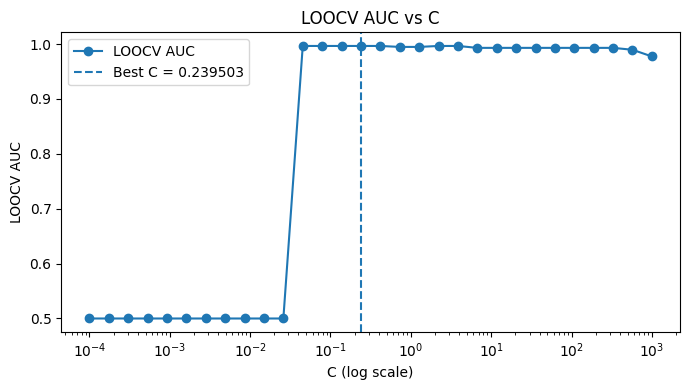


Best C: 0.2395026619987486

Summary across C grid:
    loocv_auc  loocv_accuracy_at_0.5  n_rows  n_features  n_positive  \
0    0.500000               0.200000      60          14          12   
1    0.500000               0.200000      60          14          12   
2    0.500000               0.200000      60          14          12   
3    0.500000               0.200000      60          14          12   
4    0.500000               0.200000      60          14          12   
5    0.500000               0.200000      60          14          12   
6    0.500000               0.200000      60          14          12   
7    0.500000               0.200000      60          14          12   
8    0.500000               0.200000      60          14          12   
9    0.500000               0.200000      60          14          12   
10   0.500000               0.200000      60          14          12   
11   0.996528               0.950000      60          14          12   
12   0.99652

In [13]:
drop_idx = 6  # same row dropped in the original notebook
tune_input = combined_df.iloc[[i for i in range(len(combined_df)) if i != drop_idx]]

c_tuning = tune_C_loocv_logistic(
    df=tune_input,
    feature_cols=FEATURES,
    label_col='is_insider',
    C_grid=np.logspace(-4, 3, 30),
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    plot=True,
)

print(f"\nBest C: {c_tuning['best_C']}")
print('\nSummary across C grid:')
print(c_tuning['summary_df'])

In [14]:
best_result = c_tuning['best_result']
behavior_model = c_tuning['best_model']

print('=== best LOOCV result ===')
for k, v in best_result['metrics'].items():
    print(f'  {k}: {v}')

print('\n=== top coefficients (by |coef|) ===')
best_result['coef_summary'].head(25)

=== best LOOCV result ===
  loocv_auc: 0.9965277777777778
  loocv_accuracy_at_0.5: 0.9666666666666667
  n_rows: 60
  n_features: 14
  n_positive: 12
  n_negative: 48
  C: 0.2395026619987486

=== top coefficients (by |coef|) ===


,feature,mean_coef,median_coef,std_coef,mean_abs_coef,median_abs_coef,nonzero_frac,positive_frac,negative_frac
0,adaptive_markout_raw_grosswt_h0p150,0.515373,0.438458,0.355945,0.515373,0.438458,1.000000,1.000000,0.0
1,adaptive_markout_raw_grosswt_h0p030,0.501467,0.475832,0.312691,0.501467,0.475832,1.000000,1.000000,0.0
2,adaptive_markout_raw_grosswt_h0p070,0.473194,0.382779,0.323255,0.473194,0.382779,1.000000,1.000000,0.0
3,unrealized_edge_per_open_token,0.485041,0.433473,0.290160,0.485041,0.433473,0.966667,0.966667,0.0
4,adaptive_minus_realized_alpha1p0_h0p030,0.005019,0.000000,0.027266,0.005019,0.000000,0.033333,0.033333,0.0
5,adaptive_minus_realized_alpha1p0_h0p070,0.000330,0.000000,0.002228,0.000330,0.000000,0.033333,0.033333,0.0
6,adaptive_late_spike_edge_grosswt_h0p030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
7,adaptive_markout_latespike_adj_grosswt_h0p070,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
8,adaptive_minus_realized_alpha0p5_h0p070,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
9,adaptive_plus_realized_alpha0p5_h0p070,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


## Misclassified rows under the tuned model

In [15]:
mis_df = get_misclassified_rows(
    behavior_model,
    combined_df[FEATURES],
    combined_df['is_insider'],
)
print(f'{len(mis_df)} misclassified rows')
mis_df

3 misclassified rows


,unrealized_edge_per_open_token,adaptive_markout_raw_grosswt_h0p030,adaptive_markout_raw_grosswt_h0p070,adaptive_markout_raw_grosswt_h0p150,adaptive_late_spike_edge_grosswt_h0p030,adaptive_markout_latespike_adj_grosswt_h0p070,adaptive_plus_realized_alpha0p5_h0p070,adaptive_plus_realized_alpha1p0_h0p030,adaptive_plus_realized_alpha1p0_h0p070,adaptive_minus_realized_alpha0p5_h0p070,adaptive_minus_realized_alpha1p0_h0p030,adaptive_minus_realized_alpha1p0_h0p070,low_buy_high_sell_pctl,realized_pnl_per_matched_token,true_label,pred_proba,pred_label,misclassified
6,5.659791e-07,2.870908e-07,2.870908e-07,2.870908e-07,0.000000,2.870908e-07,0.116099,0.232197,0.232197,-0.116098,-0.232196,-0.232196,0.500000,0.458821,1,0.224065,0,True
50,2.730380e-01,2.722687e-01,2.722687e-01,2.722687e-01,0.000000,2.722687e-01,0.302802,0.333334,0.333334,0.241736,0.211203,0.211203,0.215821,0.160030,0,0.533698,1,True
51,4.390669e-01,4.380279e-01,4.380279e-01,4.380279e-01,0.438028,0.000000e+00,0.000221,0.000441,0.000441,-0.000221,-0.000441,-0.000441,0.000000,0.060000,0,0.725772,1,True


In [16]:
# Add wallet + slug context to make it easier to inspect each error
if len(mis_df) > 0:
    mis_with_id = mis_df.join(
        combined_df[['wallet', 'market_slug', 'is_insider']],
    )
    display_cols = ['wallet', 'market_slug', 'is_insider', 'y_pred', 'pred_prob']
    display_cols = [c for c in display_cols if c in mis_with_id.columns]
    mis_with_id[display_cols]
else:
    print('No misclassifications.')

## Save the trained model for use in `insiders.ipynb`

Pickle the fitted pipeline plus the metadata needed to reproduce a single (wallet, market) feature row at inference time.

In [1]:
import pickle

artifact = {
    "model": behavior_model,
    "features": FEATURES,
    "major_move_kwargs": MAJOR_MOVE_KWARGS,
}

with open("behavior_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print(f"Saved behavior_model.pkl with {len(FEATURES)} features")

NameError: name 'behavior_model' is not defined

## Hunt for more insiders

Use the trained `behavior_model` to score new candidate `(wallet, market_slug)` pairs. `check_candidate` plots the wallet's trades on the market's YES-price history and prints the model's predicted probability of being an insider. Reuses the existing `market_cache` so re-checking a market we've already fetched is instant; the first call on a brand-new market triggers a fetch from the subgraph.

In [5]:
from polycluster import (
    map_trades_to_history,
    normalize_trades_to_yes_df,
    plot_user_on_history,
)


def _ensure_market_cached(slug: str) -> dict:
    """Fetch + parse a market once and store it in ``market_cache``."""
    if slug in market_cache:
        return market_cache[slug]

    print(f'Fetching market: {slug}')
    market = get_market_by_slug(slug)
    events = get_market_orderfilled_events(market, verbose=True)
    history = build_history_df_from_orderfilled(
        events, market.yes_token_id, market.no_token_id,
    )
    parsed = parse_orderfilled_events(events, market.token_ids, market.outcomes)

    market_cache[slug] = {
        'market': market,
        'events': events,
        'history': history,
        'parsed': parsed,
    }
    print(f'  cached: events={len(events)}, wallets={len(parsed["wallet_trades"])}')
    return market_cache[slug]


def check_candidate(wallet: str, slug: str) -> float:
    """Score one (wallet, market) pair and plot the wallet's trade history."""
    wallet = wallet.lower()
    cache = _ensure_market_cached(slug)
    market = cache['market']
    history = cache['history']
    user_trades = cache['parsed']['wallet_trades'].get(wallet, [])

    feats = build_feature_row(wallet, slug)

    row_df = pd.DataFrame([feats])
    row_df = impute_feature_only_df(row_df, FEATURES)
    prob = float(behavior_model.predict_proba(row_df[FEATURES])[:, 1][0])

    trades_df = normalize_trades_to_yes_df(
        user_trades,
        yes_token=market.yes_token_id,
        no_token=market.no_token_id,
    )
    mapped_df = map_trades_to_history(trades_df, history)
    plot_user_on_history(mapped_df, history)

    print(f'\nPredicted probability of being an insider: {prob:.4f}')
    return prob

### Run a candidate

Edit `WALLET` and `SLUG` and re-run the cell.

In [6]:
WALLET = '0xee50a31c3f5a7c77824b12a941a54388a2827ed6'
SLUG = 'will-d4vd-be-the-1-searched-person-on-google-this-year'

check_candidate(WALLET, SLUG)

NameError: name 'market_cache' is not defined